<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Cancer-Phenotype-Predictor-Genomic-Expression-Analysis/blob/main/Cancer_Phenotype_Predictor_Genomic_Expression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# 1. Load the dataset
# Since the file is in the root directory, you can call it directly
df = pd.read_csv('gene_expression.csv')

# 2. View the first 5 rows to understand the structure
print("--- First 5 rows ---")
print(df.head())

# 3. Check the dimensions (Rows, Columns)
print("\n--- Data Dimensions ---")
print(f"Shape: {df.shape}")

# 4. Get column names and data types
print("\n--- Column Info ---")
print(df.info())

--- First 5 rows ---
   Gene One  Gene Two  Cancer Present
0       4.3       3.9               1
1       2.5       6.3               0
2       5.7       3.9               1
3       6.1       6.2               0
4       7.4       3.4               1

--- Data Dimensions ---
Shape: (3000, 3)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB
None


Model Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       328
           1       0.82      0.86      0.84       272

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



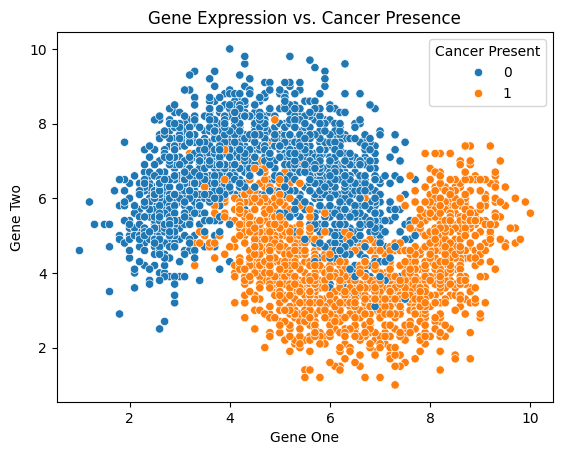

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare features (X) and target (y)
X = df[['Gene One', 'Gene Two']]
y = df['Cancer Present']

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Visualize the decision boundary
sns.scatterplot(data=df, x='Gene One', y='Gene Two', hue='Cancer Present')
plt.title("Gene Expression vs. Cancer Presence")
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Use a Random Forest instead
# It creates many 'decision trees' to capture the complex curves
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Now evaluate again
y_pred = model.predict(X_test)
print(f"New Accuracy: {accuracy_score(y_test, y_pred):.2f}")

New Accuracy: 0.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


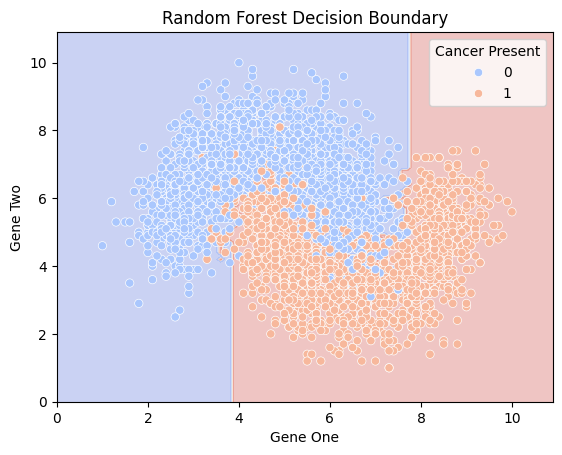

In [7]:
import numpy as np

# Create a grid of points to see the model's 'territory'
x_min, x_max = X['Gene One'].min() - 1, X['Gene One'].max() + 1
y_min, y_max = X['Gene Two'].min() - 1, X['Gene Two'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict for every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
sns.scatterplot(data=df, x='Gene One', y='Gene Two', hue='Cancer Present', palette='coolwarm')
plt.title("Random Forest Decision Boundary")
plt.show()

In [8]:
# Run this in a new cell
import pandas as pd
importances = pd.Series(model.feature_importances_, index=['Gene One', 'Gene Two'])
print(importances)

Gene One    0.48199
Gene Two    0.51801
dtype: float64


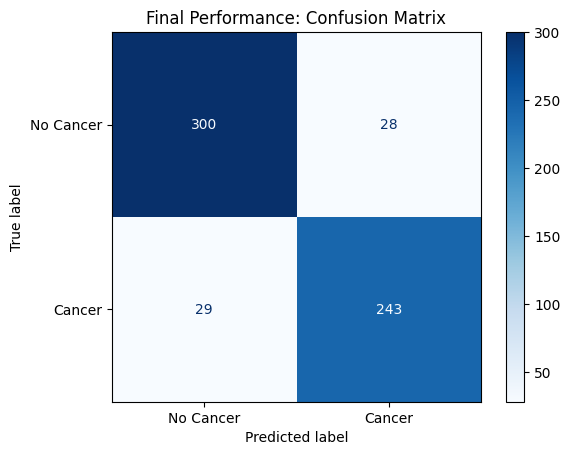

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancer', 'Cancer'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Performance: Confusion Matrix")
plt.show()